# Assignment 2 by: Ferdinand Jacques Liauw (s4150022)


# Data Sampling

In [1]:
# You may create the samples (as required) for tasks first.
# Feel free to comment this code afterwards (to avoid unnecessary re-sampling in later runs).

import pandas as pd
import numpy as np

# Load the main dataset
try:
    main_df = pd.read_csv('A2data.csv')
    print("Successfully loaded A2data.csv. Original shape:", main_df.shape)

    # Clean the dataframe by dropping rows with any missing values before sampling
    df_cleaned = main_df.dropna()
    print("Shape after removing all missing values:", df_cleaned.shape)

except FileNotFoundError:
    print("A2data.csv not found. Make sure it's in the same directory.")
    df_cleaned = None

# This part creates the sample files with the correct sizes from the cleaned dataframe.
student_id = 's4150022'

if df_cleaned is not None:
    # Task 1: 200 instances
    sample1 = df_cleaned.sample(n=200, random_state=101)
    sample1.to_csv(f'{student_id}-A2SampleOne.csv', index=False)
    print(f"Sample file 1 (n=200) created: '{student_id}-A2SampleOne.csv'")

    # Task 2: 1000 instances
    sample2 = df_cleaned.sample(n=1000, random_state=202)
    sample2.to_csv(f'{student_id}-A2SampleTwo.csv', index=False)
    print(f"Sample file 2 (n=1000) created: '{student_id}-A2SampleTwo.csv'")

    # Task 3: 600 instances
    sample3 = df_cleaned.sample(n=600, random_state=303)
    sample3.to_csv(f'{student_id}-A2SampleThree.csv', index=False)
    print(f"Sample file 3 (n=600) created: '{student_id}-A2SampleThree.csv'")

Successfully loaded A2data.csv. Original shape: (1588, 7)
Shape after removing all missing values: (1465, 7)
Sample file 1 (n=200) created: 's4150022-A2SampleOne.csv'
Sample file 2 (n=1000) created: 's4150022-A2SampleTwo.csv'
Sample file 3 (n=600) created: 's4150022-A2SampleThree.csv'


# Task 1: Regression


Missing values in Task 1 sample: 0
Displaying relationship between volatile_acidity and pH


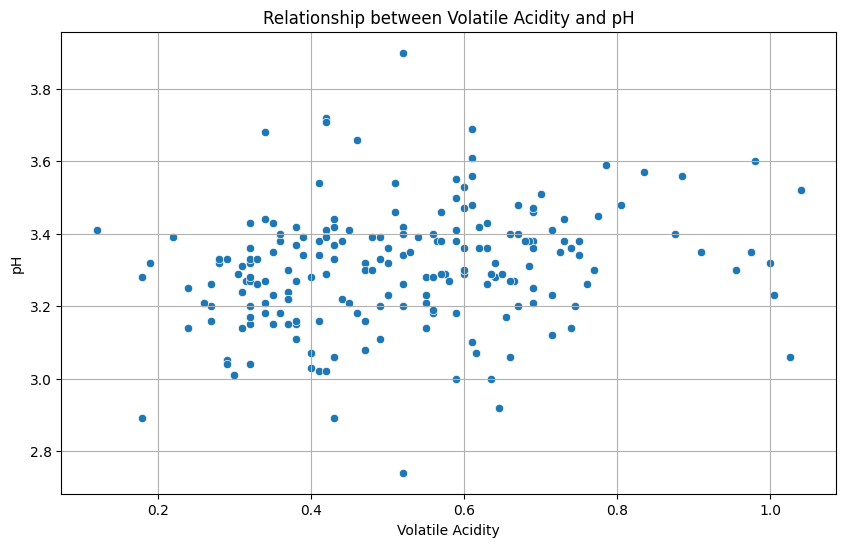


--- Regression Model Evaluation ---
R-squared: 0.0455
Mean Squared Error: 0.0210
Model Coefficients (slope): 0.1857
Model Intercept: 3.2037

Displaying data points with the linear model


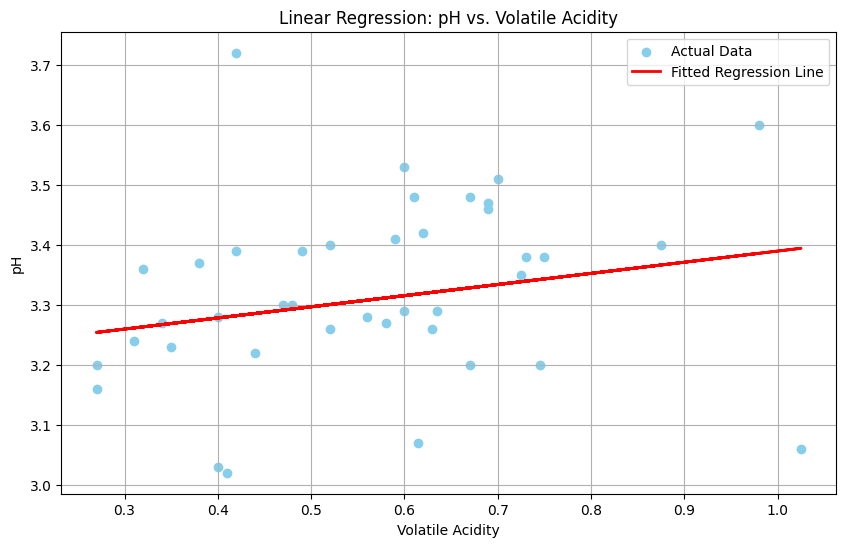

In [2]:
# Start from here to write your code for Task 1.
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load the first sample (already cleaned during sampling)
df_task1 = pd.read_csv('s4150022-A2SampleOne.csv')

# Although the sample is clean, this step ensures robustness.
print(f"Missing values in Task 1 sample: {df_task1.isnull().sum().sum()}")


# 1. Display the relationship between 'volatile_acidity' and 'pH'
print("Displaying relationship between volatile_acidity and pH")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_task1, x='volatile_acidity', y='pH')
plt.title('Relationship between Volatile Acidity and pH')
plt.xlabel('Volatile Acidity')
plt.ylabel('pH')
plt.grid(True)
plt.show()

# 2. Build the linear regression model
# Independent variable (X) = volatile_acidity
# Dependent variable (y) = pH
X = df_task1[['volatile_acidity']]
y = df_task1['pH']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Make predictions
y_pred = reg_model.predict(X_test)

# Evaluate the model's performance
print("\n--- Regression Model Evaluation ---")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Model Coefficients (slope): {reg_model.coef_[0]:.4f}")
print(f"Model Intercept: {reg_model.intercept_:.4f}")


# Visualize the data points along with the linear model
print("\nDisplaying data points with the linear model")
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='skyblue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Fitted Regression Line')
plt.title('Linear Regression: pH vs. Volatile Acidity')
plt.xlabel('Volatile Acidity')
plt.ylabel('pH')
plt.legend()
plt.grid(True)
plt.show()

# Task 2: Classification

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# Load the second sample for this task
df_task2 = pd.read_csv('s4150022-A2SampleTwo.csv')
print("Original shape of Task 2 sample:", df_task2.shape)

# Cek dan hapus missing values (NaN)
print("Missing values before cleaning:\n", df_task2.isnull().sum())
df_task2.dropna(inplace=True)
print("\nShape after dropping NaN values:", df_task2.shape)
# ----------------------------------------------------

# Create a categorical target: 'good' (>=7) vs 'bad' (<7)
df_task2['quality_label'] = df_task2['quality'].apply(lambda x: 'good' if x >= 7 else 'bad')

# Define features (X) and the new target label (y)
X = df_task2.drop(['quality', 'quality_label'], axis=1)
y = df_task2['quality_label']

# Scale the features for kNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

print("\nClassification data prepared and split.")
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Original shape of Task 2 sample: (1000, 7)
Missing values before cleaning:
 volatile_acidity        0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Shape after dropping NaN values: (1000, 7)

Classification data prepared and split.
Training set size: 750
Testing set size: 250


## kNN

In [4]:
# Standard kNN classifier with k=5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluation
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Standard kNN (k=5) Accuracy: {acc_knn:.4f}")
print("\nClassification Report for standard kNN:")
print(classification_report(y_test, y_pred_knn))

Standard kNN (k=5) Accuracy: 0.8960

Classification Report for standard kNN:
              precision    recall  f1-score   support

         bad       0.93      0.95      0.94       211
        good       0.70      0.59      0.64        39

    accuracy                           0.90       250
   macro avg       0.81      0.77      0.79       250
weighted avg       0.89      0.90      0.89       250



## Modified kNN

In [5]:
# Modified kNN using distance weighting
knn_mod_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_mod_model.fit(X_train, y_train)

# Predictions
y_pred_knn_mod = knn_mod_model.predict(X_test)

# Evaluation
acc_knn_mod = accuracy_score(y_test, y_pred_knn_mod)
print(f"Modified kNN (distance-weighted, k=5) Accuracy: {acc_knn_mod:.4f}")
print("\nClassification Report for Modified kNN:")
print(classification_report(y_test, y_pred_knn_mod))

Modified kNN (distance-weighted, k=5) Accuracy: 0.9120

Classification Report for Modified kNN:
              precision    recall  f1-score   support

         bad       0.95      0.95      0.95       211
        good       0.72      0.72      0.72        39

    accuracy                           0.91       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.91      0.91      0.91       250



## Decision Tree & comparison

In [6]:
# Implementing hyperparameter tuning for Decision Tree ---
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
# We will tune max_depth and min_samples_leaf
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Create a Decision Tree classifier
dt_base = DecisionTreeClassifier(random_state=42)

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=dt_base, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='accuracy')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

best_dt_model = grid_search.best_estimator_

# Predictions using the best model
y_pred_dt = best_dt_model.predict(X_test)

# Evaluation
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nTuned Decision Tree Accuracy: {acc_dt:.4f}")

# Final comparison
print("\n--- Final Classification Accuracy Comparison ---")
print(f"1. Standard kNN:              {acc_knn:.4f}")
print(f"2. Modified kNN (Weighted):   {acc_knn_mod:.4f}")
print(f"3. Tuned Decision Tree:       {acc_dt:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters found: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10}

Tuned Decision Tree Accuracy: 0.8680

--- Final Classification Accuracy Comparison ---
1. Standard kNN:              0.8960
2. Modified kNN (Weighted):   0.9120
3. Tuned Decision Tree:       0.8680


/tmp/ipython-input-465416348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  splot1 = sns.barplot(x=['kNN', 'Modified kNN'], y=[acc_knn, acc_knn_mod], palette='viridis')


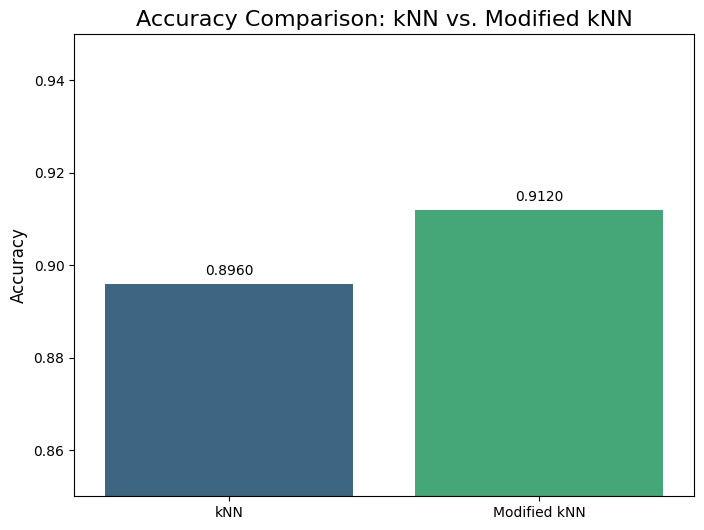

/tmp/ipython-input-465416348.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  splot2 = sns.barplot(x=['kNN', 'Decision Tree'], y=[acc_knn, acc_dt], palette='plasma')


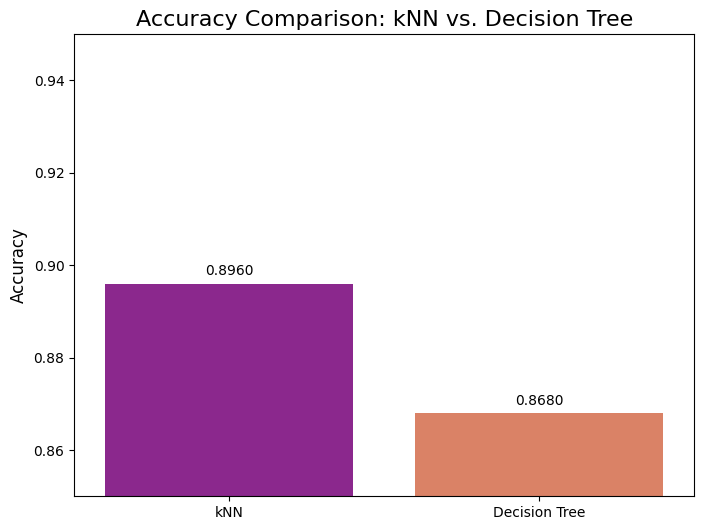

In [7]:
# 1. kNN vs Modified kNN
plt.figure(figsize=(8, 6))
splot1 = sns.barplot(x=['kNN', 'Modified kNN'], y=[acc_knn, acc_knn_mod], palette='viridis')
for p in splot1.patches:
    splot1.annotate(format(p.get_height(), '.4f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
plt.title('Accuracy Comparison: kNN vs. Modified kNN', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.85, 0.95)
plt.savefig('comparison_knn_vs_mod_knn.png')
plt.show()

# 2. kNN vs Decision Tree
plt.figure(figsize=(8, 6))
splot2 = sns.barplot(x=['kNN', 'Decision Tree'], y=[acc_knn, acc_dt], palette='plasma')
for p in splot2.patches:
    splot2.annotate(format(p.get_height(), '.4f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
plt.title('Accuracy Comparison: kNN vs. Decision Tree', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.85, 0.95)
plt.savefig('comparison_knn_vs_dt.png')
plt.show()

# Task 3: Clustering

In [8]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load the third data sample for clustering
df_task3 = pd.read_csv('s4150022-A2SampleThree.csv')
print("Original shape of Task 3 sample:", df_task3.shape)

# Cek dan hapus missing values (NaN)
print("Missing values before cleaning:\n", df_task3.isnull().sum())
df_task3.dropna(inplace=True)
print("\nShape after dropping NaN values:", df_task3.shape)
# ----------------------------------------------------

# Prepare the data for clustering (no target variable needed)
X_cluster = df_task3.drop('quality', axis=1)

# Scale the features
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("\nClustering data prepared and scaled.")

Original shape of Task 3 sample: (600, 7)
Missing values before cleaning:
 volatile_acidity        0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Shape after dropping NaN values: (600, 7)

Clustering data prepared and scaled.


## k-Means

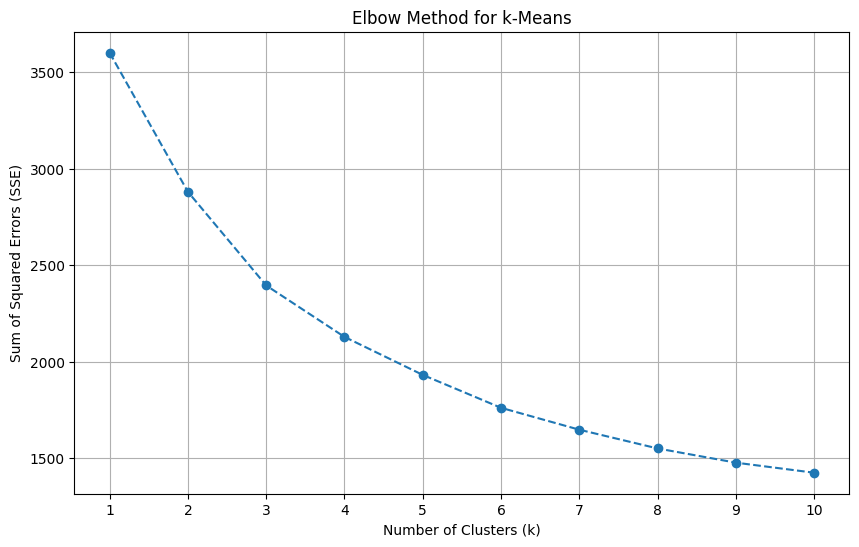

k-Means (k=3) Silhouette Score: 0.2012


In [9]:
# Find the optimal number of clusters (k) using the elbow method.
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_cluster_scaled)
    sse.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o', linestyle='--')
plt.title('Elbow Method for k-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# The elbow is around k=3, so let's use it.
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_cluster_scaled)

# Evaluate with silhouette score
score_kmeans = silhouette_score(X_cluster_scaled, kmeans_labels)
print(f"k-Means (k={k_optimal}) Silhouette Score: {score_kmeans:.4f}")

## DBSCAN & comparison

DBSCAN found 1 clusters and 16 noise points.
Cannot compute Silhouette Score for 1 or fewer clusters.


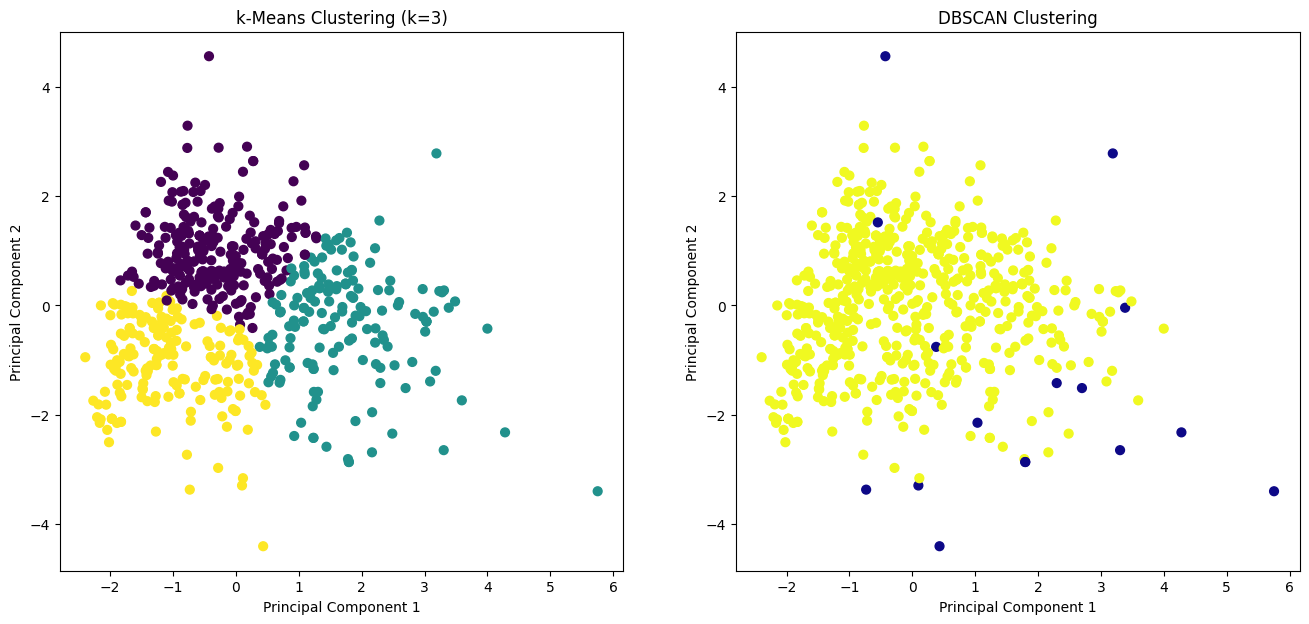

In [10]:
# DBSCAN clustering
dbscan = DBSCAN(eps=2.0, min_samples=15)
dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

# Analyze DBSCAN results
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points.")

# Evaluate with silhouette score if possible
if n_clusters > 1:
    score_dbscan = silhouette_score(X_cluster_scaled, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {score_dbscan:.4f}")
else:
    print("Cannot compute Silhouette Score for 1 or fewer clusters.")

# Visualize and compare using PCA for dimensionality reduction
pca = PCA(n_components=2)
X_cluster_pca = pca.fit_transform(X_cluster_scaled)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# k-Means plot
ax1.scatter(X_cluster_pca[:, 0], X_cluster_pca[:, 1], c=kmeans_labels, cmap='viridis', s=40)
ax1.set_title(f'k-Means Clustering (k={k_optimal})')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

# DBSCAN plot
ax2.scatter(X_cluster_pca[:, 0], X_cluster_pca[:, 1], c=dbscan_labels, cmap='plasma', s=40)
ax2.set_title(f'DBSCAN Clustering')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')

plt.show()